In [ ]:
#EDMA

In [1]:
#Titanic Kaggle

Esta celda importa la librería `pandas` para manipulación de datos y carga el archivo `train.csv` en un DataFrame llamado `datos`.

In [2]:
import pandas as pd
datos = pd.read_csv("train.csv")

Aquí se muestra la cabecera (primeras filas) del DataFrame `datos` para una vista rápida de los datos.

In [3]:
datos.head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

Esta celda genera estadísticas descriptivas del DataFrame `datos`, como la media, desviación estándar, valores mínimos y máximos de las columnas numéricas.

In [4]:
datos.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Se importa la librería `seaborn` para visualización y se crea un gráfico de barras que muestra la cantidad de pasajeros que sobrevivieron (`Survived`) y los que no.

<Axes: xlabel='Survived', ylabel='count'>

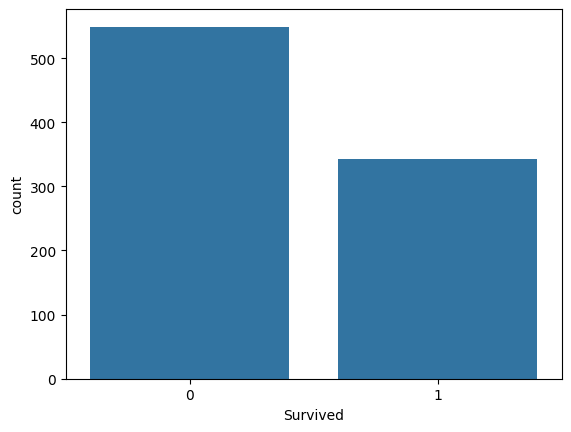

In [5]:
import seaborn as sb
sb.countplot(x="Survived", data=datos)

Esta celda expande el gráfico anterior para mostrar la cantidad de sobrevivientes y no sobrevivientes, diferenciados por género (`Sex`).

<Axes: xlabel='Survived', ylabel='count'>

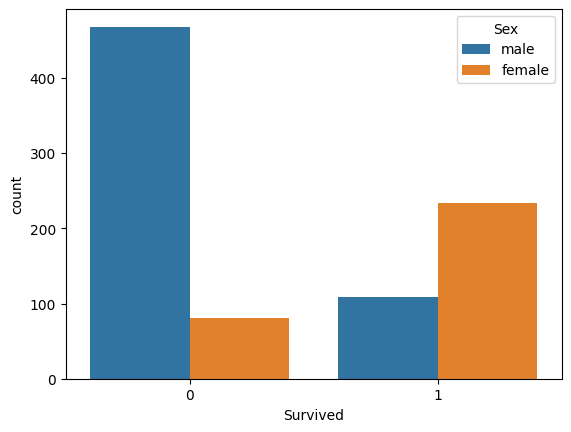

In [6]:
sb.countplot(x="Survived", hue="Sex", data=datos)

Se calcula la cantidad de valores nulos (NaN) en cada columna del DataFrame `datos` para identificar datos faltantes.

In [7]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Esta celda genera un histograma para visualizar la distribución de la edad (`Age`) de los pasajeros.

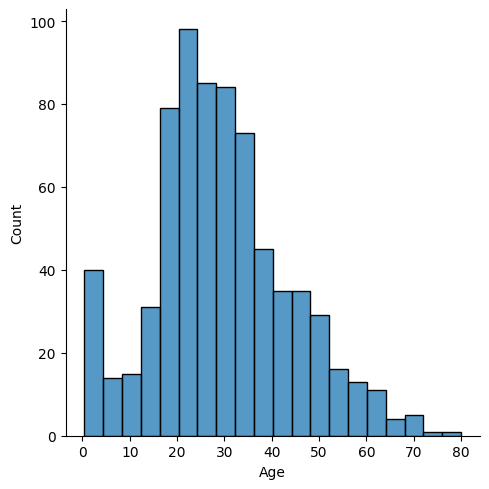

In [8]:
sb.displot(x="Age", data=datos)

Aquí se selecciona y muestra la columna 'Age' del DataFrame `datos`.

In [9]:
datos["Age"]

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


Se calcula la media de la columna 'Age', que será utilizada para rellenar los valores nulos.

In [10]:
datos["Age"].mean()

np.float64(29.69911764705882)

Esta celda muestra cómo se rellenarían los valores nulos de la columna 'Age' con la media calculada, pero sin asignar los cambios aún al DataFrame.

In [11]:
datos["Age"].fillna(datos["Age"].mean())

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Aquí se asigna el resultado de rellenar los valores nulos de 'Age' con la media de 'Age' de vuelta a la columna 'Age' del DataFrame `datos`.

In [12]:
datos["Age"] = datos["Age"].fillna(datos["Age"].mean())

Se muestra nuevamente la columna 'Age' para verificar que los valores nulos han sido rellenados.

In [13]:
datos["Age"]

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Se vuelve a calcular la suma de valores nulos en cada columna para confirmar que la columna 'Age' ya no tiene valores faltantes.

In [14]:
datos.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Esta celda elimina la columna 'Cabin' del DataFrame `datos` porque tiene una gran cantidad de valores nulos, lo que la hace poco útil para el análisis.

In [15]:
datos = datos.drop("Cabin", axis=1)

Se cuentan las ocurrencias de cada valor único en la columna 'Embarked' para ver los puertos de embarque más comunes.

In [16]:
datos["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


Esta celda elimina cualquier fila que aún contenga valores nulos en el DataFrame, asegurando un conjunto de datos limpio para el modelado.

In [17]:
datos = datos.dropna()

Se muestra la cabecera del DataFrame `datos` después de haber realizado varias operaciones de limpieza.

In [18]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Se eliminan las columnas 'Name', 'PassengerId' y 'Ticket' del DataFrame, ya que no son relevantes para el modelo de predicción de supervivencia.

In [19]:
datos = datos.drop(["Name", "PassengerId", "Ticket"], axis=1)

Esta celda crea variables dummy (codificación one-hot) para la columna categórica 'Sex', eliminando la primera columna para evitar la multicolinealidad.

In [20]:
dummies_sex = pd.get_dummies(datos["Sex"], drop_first=True)

Aquí se unen las variables dummy de 'Sex' al DataFrame `datos` y luego se elimina la columna original 'Sex'.

In [21]:
datos = datos.join(dummies_sex)
datos = datos.drop(["Sex"], axis=1)

Se crea un gráfico de barras para visualizar la cantidad de sobrevivientes y no sobrevivientes, esta vez diferenciados por el puerto de embarque ('Embarked').

<Axes: xlabel='Survived', ylabel='count'>

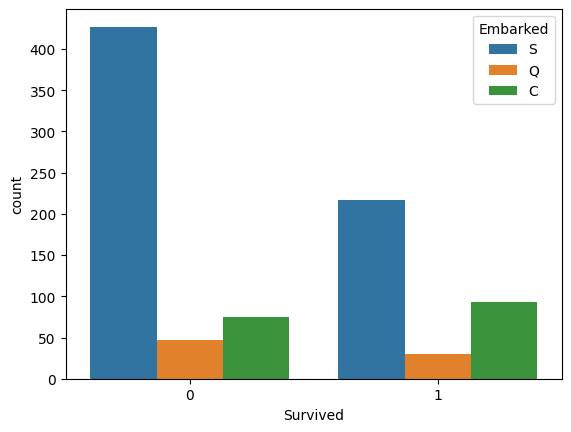

In [22]:
sb.countplot(x="Survived", data=datos, hue="Embarked")

Esta celda prepara los datos para el modelado: `x` contiene las características (todas las columnas excepto 'Survived') e `y` contiene la variable objetivo ('Survived').

In [23]:
x = datos.drop(["Survived"], axis=1)
y = datos["Survived"]

Se importa `train_test_split` de `sklearn.model_selection` para dividir los datos en conjuntos de entrenamiento y prueba. El 20% de los datos se reserva para la prueba.

In [62]:
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.2)

Se importa `DecisionTreeClassifier` y se entrena un modelo de árbol de decisión con una profundidad máxima de 10. Luego, se realizan predicciones sobre el conjunto de prueba.

In [63]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)

Se calcula la precisión (accuracy) del modelo comparando las predicciones (`predicciones`) con los valores reales (`y_pru`) del conjunto de prueba.

In [64]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pru, predicciones)

0.7921348314606742

Esta celda itera a través de diferentes valores de `max_depth` para el árbol de decisión (de 1 a 14), entrena un modelo para cada uno, realiza predicciones y almacena la precisión resultante en la lista `resultados`.

In [65]:
from sklearn.tree import DecisionTreeClassifier

resultados = []
for i in range(1, 15):
    modelo = DecisionTreeClassifier(max_depth=i)
    modelo.fit(X_ent, y_ent)
    predicciones = modelo.predict(X_pru)
    exactitud = accuracy_score(y_pru, predicciones)
    print(f"Resultado para {i}: {exactitud}")
    resultados.append(exactitud)

Resultado para 1: 0.7865168539325843
Resultado para 2: 0.7865168539325843
Resultado para 3: 0.8426966292134831
Resultado para 4: 0.8202247191011236
Resultado para 5: 0.848314606741573
Resultado para 6: 0.8146067415730337
Resultado para 7: 0.7921348314606742
Resultado para 8: 0.7752808988764045
Resultado para 9: 0.7865168539325843
Resultado para 10: 0.7865168539325843
Resultado para 11: 0.7921348314606742
Resultado para 12: 0.797752808988764
Resultado para 13: 0.7752808988764045
Resultado para 14: 0.7808988764044944


Se genera un gráfico de línea para visualizar cómo cambia la precisión del modelo en función de la profundidad máxima del árbol (`resultados`).

<Axes: >

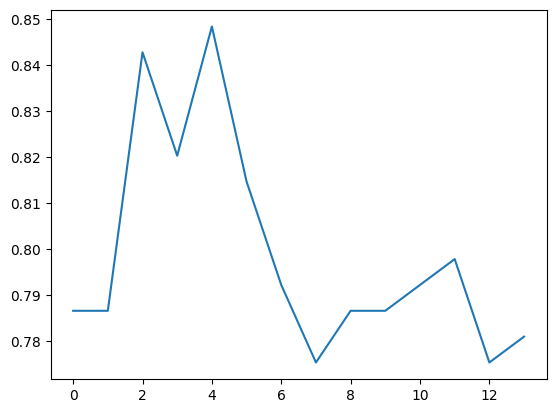

In [66]:
sb.lineplot(data=resultados)

Basándose en los resultados anteriores, se entrena un nuevo modelo de árbol de decisión con una profundidad máxima de 8 (o el valor óptimo identificado) y se evalúa nuevamente.

In [67]:
modelo = DecisionTreeClassifier(max_depth=8)
modelo.fit(X_ent, y_ent)
predicciones = modelo.predict(X_pru)
exactitud = accuracy_score(y_pru, predicciones)

Se imprime el informe de clasificación, que incluye métricas como precisión, recall y f1-score para cada clase (sobrevivió/no sobrevivió) en el conjunto de prueba.

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_pru, predicciones))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       117
           1       0.71      0.64      0.67        61

    accuracy                           0.79       178
   macro avg       0.77      0.75      0.76       178
weighted avg       0.78      0.79      0.78       178



Se crea y muestra una matriz de confusión para evaluar el rendimiento del modelo, mostrando los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

In [73]:
pd.DataFrame(confusion_matrix(y_pru, predicciones), columns=["Pred: No", "Pred: Si"], index=["Real: No", "Real: Si"])

,Pred: No,Pred: Si
Real: No,101,16
Real: Si,22,39


Esta celda muestra los nombres de las columnas utilizadas como características en el conjunto de entrenamiento (`X_ent`).

In [70]:
X_ent.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male', 'Q', 'S'], dtype='object')

Se importa `plot_tree` y `matplotlib.pyplot` para visualizar el árbol de decisión entrenado, mostrando las divisiones y las clases predichas en cada nodo.

[Text(0.41929768041237114, 0.9444444444444444, 'male <= 0.5\n0.477\n711\n[432, 279]\nMurio'),
 Text(0.20876288659793815, 0.8333333333333334, 'Pclass <= 2.5\n0.368\n247\n[60, 187]\nVivio'),
 Text(0.31403028350515466, 0.8888888888888888, 'True  '),
 Text(0.055412371134020616, 0.7222222222222222, 'Age <= 2.5\n0.096\n139\n[7, 132]\nVivio'),
 Text(0.020618556701030927, 0.6111111111111112, 'Pclass <= 1.5\n0.5\n2\n[1, 1]\nMurio'),
 Text(0.010309278350515464, 0.5, '0.0\n1\n[1, 0]\nMurio'),
 Text(0.030927835051546393, 0.5, '0.0\n1\n[0, 1]\nVivio'),
 Text(0.09020618556701031, 0.6111111111111112, 'Fare <= 13.25\n0.084\n137\n[6, 131]\nVivio'),
 Text(0.05154639175257732, 0.5, 'Age <= 53.5\n0.219\n24\n[3, 21]\nVivio'),
 Text(0.041237113402061855, 0.3888888888888889, 'Fare <= 12.825\n0.159\n23\n[2, 21]\nVivio'),
 Text(0.030927835051546393, 0.2777777777777778, '0.0\n10\n[0, 10]\nVivio'),
 Text(0.05154639175257732, 0.2777777777777778, 'Age <= 26.0\n0.26\n13\n[2, 11]\nVivio'),
 Text(0.030927835051546393

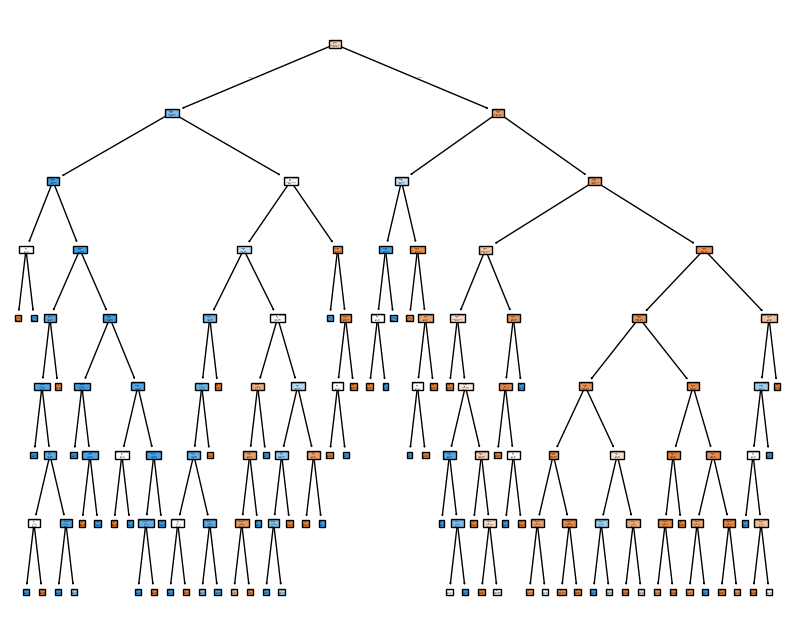

In [74]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_tree(
    modelo,
    feature_names=X_ent.columns,
    class_names=["Murio", "Vivio"],
    filled=True,
    label="none"
    )

# "Joven haga su trabajo por favor"

###### 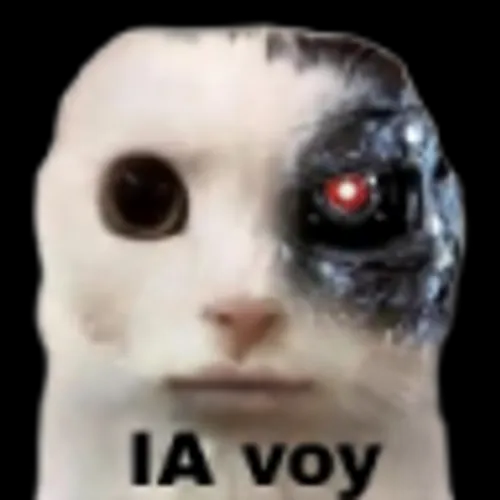